In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the folder containing your 8 CSV files
# Update this path to wherever you uploaded the CIC-IDS-2017 CSVs in your Drive
DATA_PATH = '/content/drive/MyDrive/CIC-IDS-2017/MachineLearningCVE'

# Verify the files are recognized
csv_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f" - {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8 CSV files:
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
import pandas as pd
import glob

# Use glob to grab all CSV files in the directory
all_csv_paths = glob.glob(os.path.join(DATA_PATH, "*.csv"))

# Read and concatenate all files
print("Loading and merging CSV files... This may take a moment.")
df_list = [pd.read_csv(file) for file in all_csv_paths]
df = pd.concat(df_list, ignore_index=True)

print(f"Total records loaded: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

Loading and merging CSV files... This may take a moment.
Total records loaded: 2830743
Total features: 79


In [ ]:
import numpy as np

# 1. Strip whitespace from column names
df.columns = df.columns.str.strip()

# 2. Strip whitespace from the 'Label' column just in case
df['Label'] = df['Label'].astype(str).str.strip()

# 3. Replace Infinity values with NaN, then drop all rows with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)
initial_count = df.shape[0]
df.dropna(inplace=True)
final_count = df.shape[0]

print(f"Dropped {initial_count - final_count} rows containing NaN or Infinity.")
print(f"Cleaned dataset shape: {df.shape}")

Dropped 2867 rows containing NaN or Infinity.
Cleaned dataset shape: (2827876, 79)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Filter for BENIGN traffic
normal_df = df[df['Label'] == 'BENIGN'].copy()
print(f"Total BENIGN records: {normal_df.shape[0]}")

# 2. Drop the 'Label' column to isolate numerical features
X_normal = normal_df.drop(columns=['Label'])

# (Optional) Drop other non-numeric or irrelevant columns if they exist in your specific CSV version
# e.g., 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp'
cols_to_drop = [col for col in ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Source Port', 'Destination Port'] if col in X_normal.columns]
if cols_to_drop:
    X_normal.drop(columns=cols_to_drop, inplace=True)

# 3. Split into Train and Validation sets (80/20)
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

# 4. Scale the data (Fit on training, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Validation data shape: {X_val_scaled.shape}")

Total BENIGN records: 2271320
Training data shape: (1817056, 77)
Validation data shape: (454264, 77)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train_scaled.shape[1]

# Define the Encoder
encoder_input = layers.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(encoder_input)
x = layers.Dropout(0.1)(x) # Slight dropout to prevent overfitting
x = layers.Dense(32, activation='relu')(x)
latent_representation = layers.Dense(16, activation='relu')(x)

# Define the Decoder
x = layers.Dense(32, activation='relu')(latent_representation)
x = layers.Dropout(0.1)(x)
x = layers.Dense(64, activation='relu')(x)
decoder_output = layers.Dense(input_dim, activation='linear')(x) # Linear activation because data is StandardScaled

# Compile the Autoencoder
autoencoder = models.Model(inputs=encoder_input, outputs=decoder_output)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,261 (59.61 KB)

 Trainable params: 15,261 (59.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

print("Cleaning up memory...")
# 1. Downcast to float32 (Literally cuts your RAM usage in half)
X_train_scaled = X_train_scaled.astype('float32')
X_val_scaled = X_val_scaled.astype('float32')

# Force Python to empty the trash and free up RAM immediately
gc.collect()
tf.keras.backend.clear_session()

print("Building data pipelines...")
batch_size = 256

# 2. The Map Trick: Pass the array ONCE, and map it to (input, output) dynamically
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_scaled) \
    .map(lambda x: (x, x)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(X_val_scaled) \
    .map(lambda x: (x, x)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting training on the FULL dataset...")
history = autoencoder.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping],
    verbose=1
)

Cleaning up memory...
Building data pipelines...
Starting training on the FULL dataset...
Epoch 1/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 70s 9ms/step - loss: 0.2340 - val_loss: 0.1251
Epoch 2/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 0.1639 - val_loss: 0.0806
Epoch 3/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 0.1489 - val_loss: 0.0711
Epoch 4/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 49s 7ms/step - loss: 0.1320 - val_loss: 0.0815
Epoch 5/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 46s 7ms/step - loss: 0.1268 - val_loss: 0.0694
Epoch 6/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 0.1230 - val_loss: 0.0636
Epoch 7/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 98s 9ms/step - loss: 0.1081 - val_loss: 0.0530
Epoch 8/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - loss: 0.1065 - val_loss: 0.0487
Epoch 9/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 62s 9ms/step - loss: 0.0978 - val_loss: 0.0631
Epoch 10/50
7098/7098 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - loss: 0.0983 - val_loss: 0.0933
Epoch 11/50
7098/7

In [ ]:
# Save the final model to your Drive
autoencoder.save('/content/drive/MyDrive/CIC-IDS-2017/cicids_autoencoder.keras')
print("Model successfully saved to Google Drive!")

Model successfully saved to Google Drive!


14196/14196 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step
Determined Anomaly Threshold (99th percentile): 0.3355


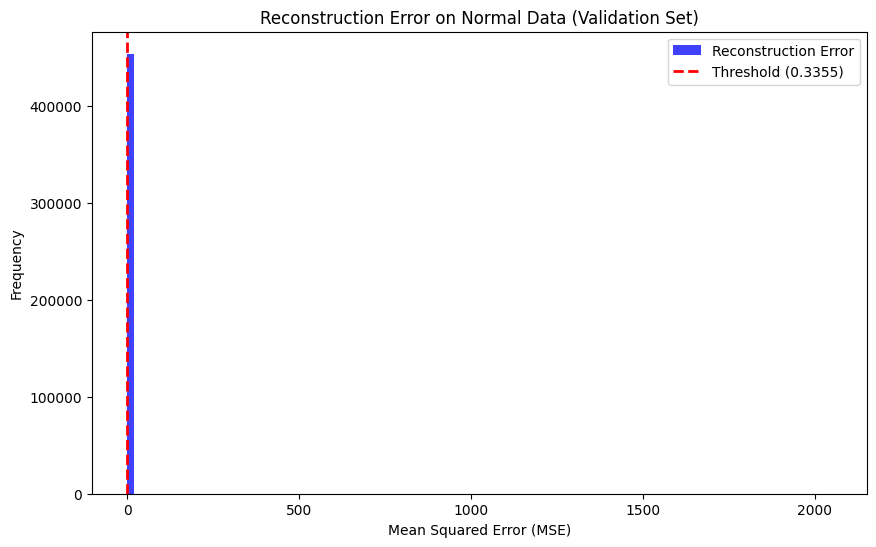

In [ ]:
import matplotlib.pyplot as plt

# 1. Get predictions (reconstructions) on the validation set
reconstructions = autoencoder.predict(X_val_scaled)

# 2. Calculate Mean Squared Error (MSE) for each record
mse = np.mean(np.power(X_val_scaled - reconstructions, 2), axis=1)

# 3. Define threshold (e.g., 99th percentile of normal validation error)
threshold = np.percentile(mse, 99)
print(f"Determined Anomaly Threshold (99th percentile): {threshold:.4f}")

# 4. Plot the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
plt.hist(mse, bins=100, alpha=0.75, color='blue', label='Reconstruction Error')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.4f})')
plt.title('Reconstruction Error on Normal Data (Validation Set)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Extracting latent representations (this may take a few seconds)...


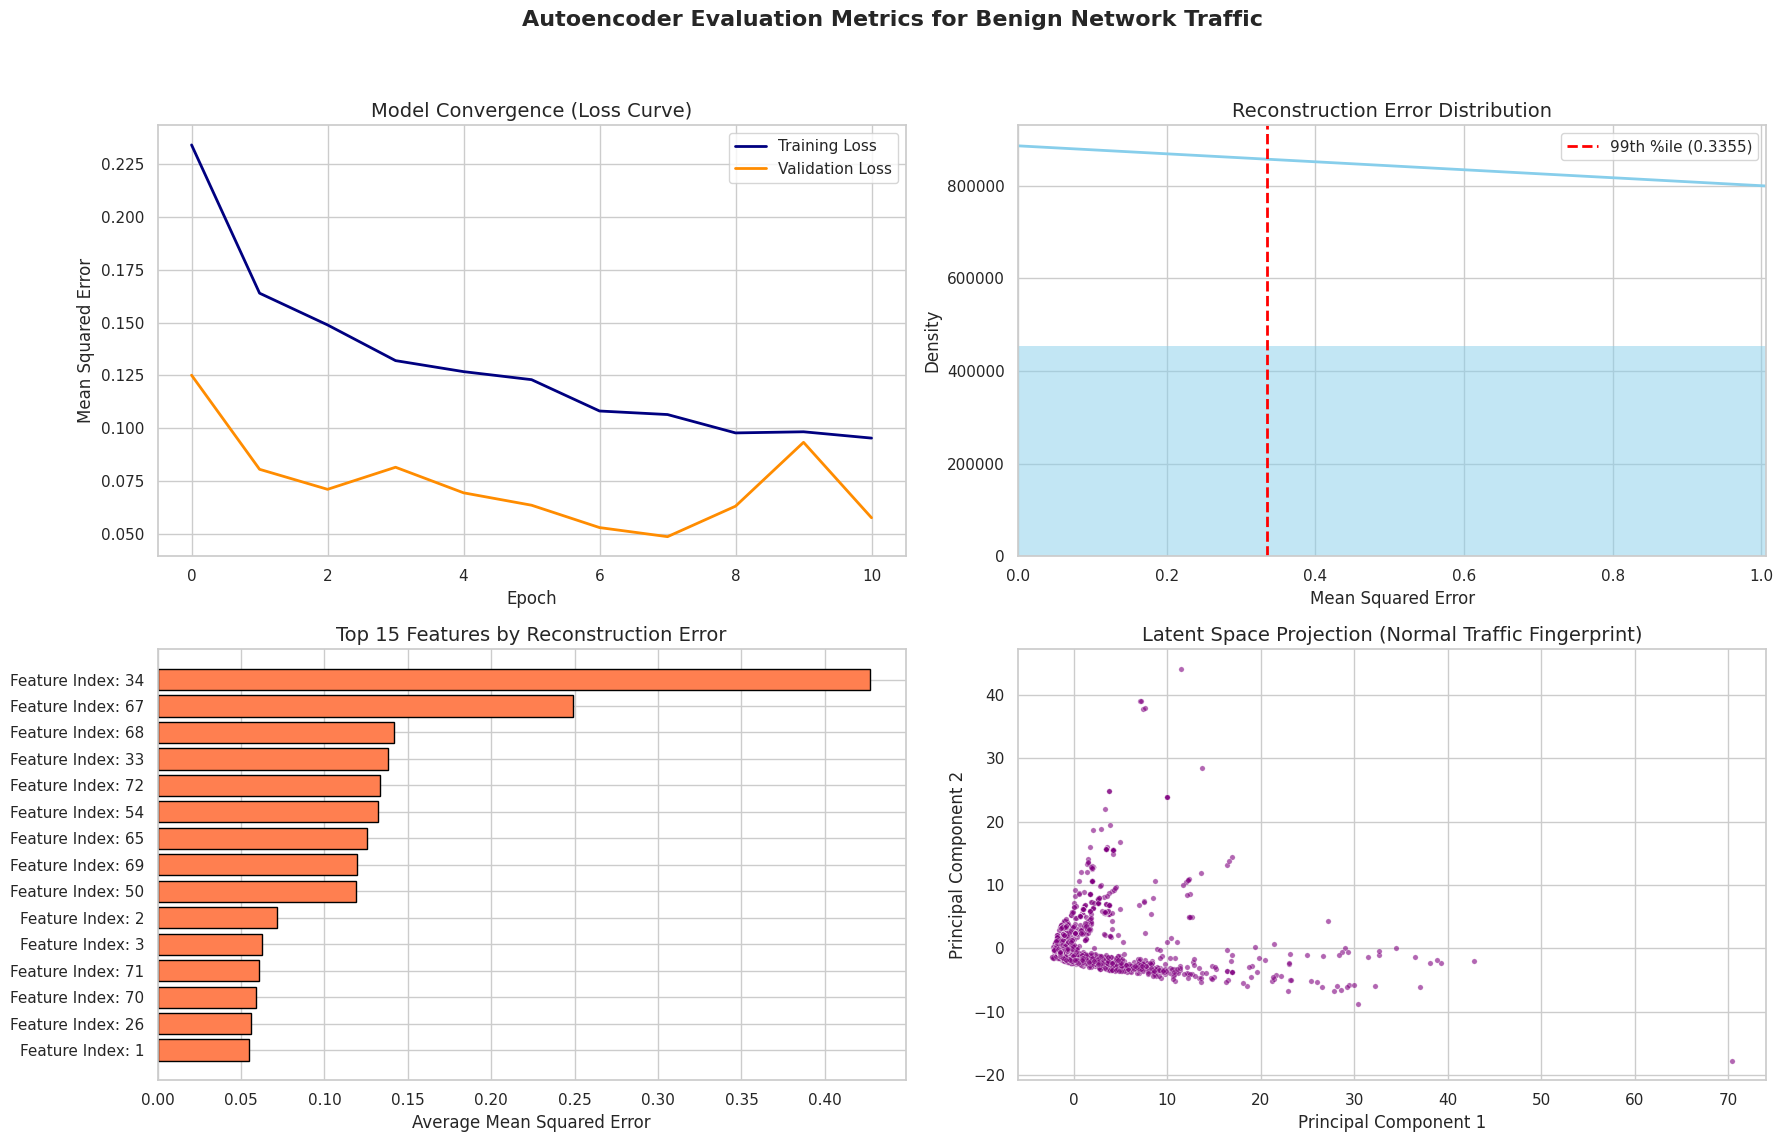

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import tensorflow as tf

# Set visual style for academic paper aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Autoencoder Evaluation Metrics for Benign Network Traffic', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# 1. Training vs Validation Loss Curve
# ---------------------------------------------------------
# Proves to your professor that the model converged properly and did not overfit
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='navy')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='darkorange')
axes[0, 0].set_title('Model Convergence (Loss Curve)', fontsize=14)
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()

# ---------------------------------------------------------
# 2. Histogram with KDE of Reconstruction Errors
# ---------------------------------------------------------
# A cleaner way to show highly skewed anomaly data
sns.histplot(x=mse, bins=1000, ax=axes[0, 1], color="skyblue", kde=True, line_kws={'linewidth': 2})
axes[0, 1].axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'99th %ile ({threshold:.4f})')
axes[0, 1].set_title('Reconstruction Error Distribution', fontsize=14)
axes[0, 1].set_xlabel('Mean Squared Error')
axes[0, 1].set_ylabel('Density')
# Zooming in to 3x the threshold to show the core distribution
axes[0, 1].set_xlim(0, threshold * 3)
axes[0, 1].legend()

# ---------------------------------------------------------
# 3. Feature-Wise Error Analysis (Explainable AI component)
# ---------------------------------------------------------
# Shows WHICH network features the autoencoder struggles to reconstruct the most
feature_mse = np.mean(np.power(X_val_scaled - reconstructions, 2), axis=0)
top_15_indices = np.argsort(feature_mse)[-15:] # Get indices of the 15 highest errors

axes[1, 0].barh(range(15), feature_mse[top_15_indices], color='coral', edgecolor='black')
axes[1, 0].set_yticks(range(15))
axes[1, 0].set_yticklabels([f"Feature Index: {i}" for i in top_15_indices])
axes[1, 0].set_title('Top 15 Features by Reconstruction Error', fontsize=14)
axes[1, 0].set_xlabel('Average Mean Squared Error')

# ---------------------------------------------------------
# 4. Latent Space Projection (PCA)
# ---------------------------------------------------------
# Visualizes the "bottleneck" layer to show how tightly the model clusters normal traffic
print("Extracting latent representations (this may take a few seconds)...")

# Isolate the encoder portion of your trained model (Input -> Dense 64 -> Dropout -> Dense 32 -> Dense 16)
encoder = tf.keras.models.Model(inputs=autoencoder.input, outputs=autoencoder.layers[4].output)

# Sample 5,000 points so the scatter plot doesn't turn into a solid block of color
sample_idx = np.random.choice(X_val_scaled.shape[0], 5000, replace=False)
latent_representation = encoder.predict(X_val_scaled[sample_idx], verbose=0)

# Reduce the 16-dimensional bottleneck down to 2 dimensions for plotting
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_representation)

sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], ax=axes[1, 1], alpha=0.6, color='purple', s=15)
axes[1, 1].set_title('Latent Space Projection (Normal Traffic Fingerprint)', fontsize=14)
axes[1, 1].set_xlabel('Principal Component 1')
axes[1, 1].set_ylabel('Principal Component 2')

# Final layout adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()